<a href="https://colab.research.google.com/github/kimathivictormutwiri-prog/sports_analysis/blob/main/day2_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
repo_path = '/content/drive/MyDrive/sports_analysis/sports_analysis'
os.chdir(repo_path)
!git pull origin main
!pip install -r requirements.txt -q
print("✅ Setup complete. Working directory:", os.getcwd())

Mounted at /content/drive
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 14 (delta 4), reused 5 (delta 1), pack-reused 0 (from 0)
Unpacking objects: 100% (14/14), 345.36 KiB | 1010.00 KiB/s, done.
From https://github.com/kimathivictormutwiri-prog/sports_analysis
 * branch            main       -> FETCH_HEAD
   da63b56..93f4de1  main       -> origin/main
Updating da63b56..93f4de1
Fast-forward
 day1_pipeline.ipynb             | 1102 +++++++++++++++++++++++++++++++++++++++
 day2_pipeline.ipynb             |   39 ++
 sports_analysis/src/detector.py |   62 +++
 3 files changed, 1203 insertions(+)
 create mode 100644 day1_pipeline.ipynb
 create mode 100644 day2_pipeline.ipynb
 create mode 100644 sports_analysis/src/detector.py
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━

In [2]:
import importlib.util

def load_class(module_name, file_path, class_name):
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return getattr(module, class_name)

VideoProcessor = load_class("video_processor", f"{repo_path}/src/video_processor.py", "VideoProcessor")
PlayerDetector = load_class("detector", f"{repo_path}/src/detector.py", "PlayerDetector")

print("✅ Both classes imported")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Both classes imported


In [3]:
import cv2

# Load detector (downloads yolov8n.pt automatically on first run)
detector = PlayerDetector(model_name="yolov8n.pt", confidence=0.4)

# Load one of your already-extracted frames
output_dir = '/content/drive/MyDrive/sports_analysis_outputs/frames'
frame = cv2.imread(f"{output_dir}/frame_0051.jpg")

# Run detection
detections = detector.detect_frame(frame)
print(f"✅ Detections found: {len(detections)}")
for d in detections[:5]:
    print(d)

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 366ms
Prepared 1 package in 87ms
Installed 1 package in 2ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 1.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


0: 288x640 13 persons, 352.9ms
Speed: 16.9ms preprocess, 352.9ms inference, 43.5ms postprocess per image at shape (1, 3, 288, 640)
✅ Detections found: 13
{'track_id': 1, 'class_id': 0, 'class_name': 'person', 'confidence': 0.7297547459602356, 'bbox': [921.363525390625, 605.7075805664062, 952.0856323242188, 694.1637573242188], 'center': [936.7245788574219, 649.9356689453125]}
{'track_id': 2, 'class_id': 0, 'class_name': 'person', 'confidence': 0.6950932741165161, 'bbox': [1485.3480224609375, 801.652587890625, 1528.0443115234375, 907.4067993164062], 'center': [1506.6961669921875, 854.5296936035156]}
{'track_id': 3, 'class_id': 0, 'class

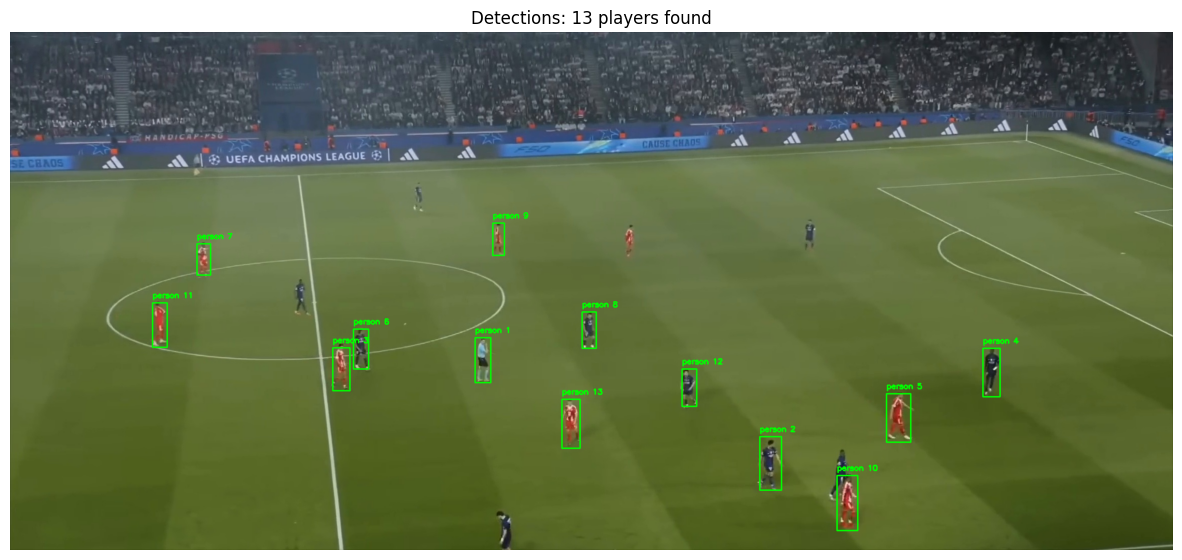

In [4]:
import matplotlib.pyplot as plt

annotated = detector.draw_detections(frame, detections)
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 8))
plt.imshow(annotated_rgb)
plt.axis('off')
plt.title(f"Detections: {len(detections)} players found")
plt.show()

In [5]:
for i in [1, 51, 101, 151, 201]:
    frame_test = cv2.imread(f"{output_dir}/frame_{i:04d}.jpg")
    if frame_test is None:
        continue
    dets = detector.detect_frame(frame_test)
    ball_found = any(d['class_id'] == 32 for d in dets)
    print(f"Frame {i}: {len(dets)} detections | Ball detected: {ball_found}")


0: 288x640 1 person, 118.3ms
Speed: 4.5ms preprocess, 118.3ms inference, 1.2ms postprocess per image at shape (1, 3, 288, 640)
Frame 1: 1 detections | Ball detected: False

0: 288x640 13 persons, 113.0ms
Speed: 3.8ms preprocess, 113.0ms inference, 2.4ms postprocess per image at shape (1, 3, 288, 640)
Frame 51: 13 detections | Ball detected: False

0: 288x640 10 persons, 107.9ms
Speed: 3.9ms preprocess, 107.9ms inference, 1.3ms postprocess per image at shape (1, 3, 288, 640)
Frame 101: 10 detections | Ball detected: False

0: 288x640 1 person, 103.8ms
Speed: 2.4ms preprocess, 103.8ms inference, 4.2ms postprocess per image at shape (1, 3, 288, 640)
Frame 151: 1 detections | Ball detected: False

0: 288x640 5 persons, 262.2ms
Speed: 3.1ms preprocess, 262.2ms inference, 3.8ms postprocess per image at shape (1, 3, 288, 640)
Frame 201: 5 detections | Ball detected: False


In [6]:
detector_sensitive = PlayerDetector(model_name="yolov8n.pt", confidence=0.15)

for i in [1, 51, 101, 151, 201]:
    frame_test = cv2.imread(f"{output_dir}/frame_{i:04d}.jpg")
    if frame_test is None:
        continue
    dets = detector_sensitive.detect_frame(frame_test)
    ball_dets = [d for d in dets if d['class_id'] == 32]
    print(f"Frame {i}: {len(dets)} total | Ball detections: {len(ball_dets)}")
    for b in ball_dets:
        print(f"  Ball confidence: {b['confidence']:.3f}")


0: 288x640 13 persons, 119.0ms
Speed: 2.5ms preprocess, 119.0ms inference, 1.2ms postprocess per image at shape (1, 3, 288, 640)
Frame 1: 13 total | Ball detections: 0

0: 288x640 2 persons, 106.0ms
Speed: 3.4ms preprocess, 106.0ms inference, 1.2ms postprocess per image at shape (1, 3, 288, 640)
Frame 51: 2 total | Ball detections: 0

0: 288x640 1 person, 101.0ms
Speed: 2.9ms preprocess, 101.0ms inference, 1.2ms postprocess per image at shape (1, 3, 288, 640)
Frame 101: 1 total | Ball detections: 0

0: 288x640 24 persons, 111.6ms
Speed: 4.2ms preprocess, 111.6ms inference, 1.7ms postprocess per image at shape (1, 3, 288, 640)
Frame 151: 24 total | Ball detections: 0

0: 288x640 17 persons, 112.5ms
Speed: 3.1ms preprocess, 112.5ms inference, 1.5ms postprocess per image at shape (1, 3, 288, 640)
Frame 201: 17 total | Ball detections: 0
